build the mapping + check match rate

XML files downloaded from InBreast Kaggle: 
https://www.kaggle.com/datasets/tommyngx/inbreast2012?resource=download

The paper uses a YOLO technique

In [1]:
from pathlib import Path
import re
import pandas as pd

DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
XML_DIR   = Path("data/raw/AllXML")  # or data/raw/inbreast_kaggle/AllXML if you rename it

def leading_id(stem: str) -> str:
    m = re.match(r"(\d+)", stem)
    return m.group(1) if m else stem

dicoms = sorted(DICOM_DIR.glob("*.dcm"))
xmls   = sorted(XML_DIR.glob("*.xml"))

# map id -> path (keep lists in case of duplicates)
dicom_map = {}
for p in dicoms:
    cid = leading_id(p.stem)
    dicom_map.setdefault(cid, []).append(p)

xml_map = {leading_id(p.stem): p for p in xmls}

rows = []
for cid, dcm_list in dicom_map.items():
    for dcm in dcm_list:
        rows.append({
            "case_id": cid,
            "dicom_name": dcm.name,
            "dicom_path": str(dcm),
            "xml_path": str(xml_map[cid]) if cid in xml_map else None,
            "has_xml": cid in xml_map
        })

link_df = pd.DataFrame(rows)

print("DICOM files:", len(dicoms))
print("XML files:", len(xmls))
print("DICOMs with XML:", int(link_df["has_xml"].sum()))
print("DICOMs missing XML:", int((~link_df["has_xml"]).sum()))

display(link_df.sample(10, random_state=0))

# show a few missing examples (useful sanity)
missing = link_df[~link_df["has_xml"]].head(20)
if len(missing):
    print("\nExamples missing XML:")
    display(missing[["case_id","dicom_name"]])

DICOM files: 410
XML files: 343
DICOMs with XML: 343
DICOMs missing XML: 67


,case_id,dicom_name,dicom_path,xml_path,has_xml
295,50998086,50998086_66adfbb4f19c76d2_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\50998086_66adfbb4f1...,data\raw\AllXML\50998086.xml,True
76,22613624,22613624_dcafa6ba6374ec07_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\22613624_dcafa6ba63...,data\raw\AllXML\22613624.xml,True
261,50996379,50996379_6aba0b402889a16f_MG_L_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\50996379_6aba0b4028...,None,False
374,53582476,53582476_3f0db31711fc9795_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\53582476_3f0db31711...,data\raw\AllXML\53582476.xml,True
299,50998231,50998231_f34ee0ab6591b792_MG_L_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\50998231_f34ee0ab65...,data\raw\AllXML\50998231.xml,True
145,24055176,24055176_606e9b184978a350_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\24055176_606e9b1849...,data\raw\AllXML\24055176.xml,True
90,22614127,22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\22614127_6bd24a0a42...,data\raw\AllXML\22614127.xml,True
10,20587294,20587294_e634830794f5c1bd_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\20587294_e634830794...,data\raw\AllXML\20587294.xml,True
215,50993670,50993670_b03f1dd34eb3c55f_MG_L_ML_ANON.dcm,data\raw\inbreast\ALL-IMGS\50993670_b03f1dd34e...,data\raw\AllXML\50993670.xml,True
328,51048972,51048972_f3e93e889a7746f0_MG_R_CC_ANON.dcm,data\raw\inbreast\ALL-IMGS\51048972_f3e93e889a...,data\raw\AllXML\51048972.xml,True



Examples missing XML:


,case_id,dicom_name
32,20588138,20588138_8d0b9620c53c0268_MG_R_ML_ANON.dcm
33,20588164,20588164_8d0b9620c53c0268_MG_R_CC_ANON.dcm
61,22580218,22580218_5530d5782fc89dd7_MG_L_CC_ANON.dcm
63,22580270,22580270_5530d5782fc89dd7_MG_L_ML_ANON.dcm
83,22613848,22613848_45c7f44839fd9e68_MG_L_ML_ANON.dcm
85,22613944,22613944_f23fa352e7de3dc7_MG_L_CC_ANON.dcm
87,22613996,22613996_f23fa352e7de3dc7_MG_L_ML_ANON.dcm
110,22670442,22670442_7e677f3d530e41ed_MG_R_CC_ANON.dcm
112,22670488,22670488_7e677f3d530e41ed_MG_R_ML_ANON.dcm
115,22670643,22670643_e15a16f87b4f9782_MG_L_CC_ANON.dcm


Cell A — Parse this plist XML into ROIs (correct keys: Name, Point_px)

In [3]:
from pathlib import Path
import plistlib
import re
import numpy as np

def parse_point_px_list(point_px_list):
    """
    point_px_list: ["(x, y)", "(x, y)", ...]
    returns Nx2 float array [[x,y], ...]
    """
    pts = []
    for s in point_px_list:
        nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
        if len(nums) >= 2:
            pts.append([float(nums[0]), float(nums[1])])
    return np.array(pts, dtype=np.float32)

def parse_inbreast_plist_xml(xml_path: Path, image_index=0):
    """
    Returns list of ROIs:
      [{"name": str, "type": int|None, "points_px": Nx2 float, "n_points": int}, ...]
    """
    xml_path = Path(xml_path)
    with open(xml_path, "rb") as f:
        data = plistlib.load(f)

    images = data.get("Images", [])
    if not images:
        return []

    img_entry = images[image_index]
    rois_raw = img_entry.get("ROIs", [])
    rois = []

    for r in rois_raw:
        name = r.get("Name", "ROI")
        npts = int(r.get("NumberOfPoints", 0) or 0)
        typ  = r.get("Type", None)

        pts = parse_point_px_list(r.get("Point_px", []))
        # Some files may have mismatch between NumberOfPoints and len(Point_px); trust actual list
        if pts.shape[0] == 0:
            continue

        rois.append({
            "name": str(name),
            "type": typ,
            "points_px": pts,        # [[x,y], ...]
            "n_points": int(pts.shape[0]),
        })

    return rois

Cell B — Turn ROIs into masks (polygon ROIs vs point ROIs)

If ROI has ≥ 3 points ⇒ polygon mask (fillPoly)

If ROI has 1–2 points ⇒ “point-ROI” mask (draw circles around points)

In [4]:
import numpy as np
import cv2

def roi_to_mask(roi, shape_hw, point_radius=8):
    """
    roi: dict from parse_inbreast_plist_xml
    shape_hw: (H, W)
    """
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)
    pts = roi["points_px"]

    # pts are (x,y); OpenCV wants int32, and for fillPoly: shape (N,1,2)
    pts_i = np.round(pts).astype(np.int32)
    pts_i[:, 0] = np.clip(pts_i[:, 0], 0, W-1)  # x
    pts_i[:, 1] = np.clip(pts_i[:, 1], 0, H-1)  # y

    if pts_i.shape[0] >= 3:
        cv2.fillPoly(mask, [pts_i], 1)
    else:
        # calcification-style: 1 point per ROI, paint small disk(s)
        for (x, y) in pts_i:
            cv2.circle(mask, (int(x), int(y)), int(point_radius), 1, thickness=-1)

    return mask

Cell C — Load your preprocessed image and overlay specific ROI types

stem: 22614522_2dec4948fbe6336d_MG_L_CC_ANON
XML: 22614522.xml
ROIs found: 20
ROI name counts: {'Calcification': np.int64(19), 'Mass': np.int64(1)}


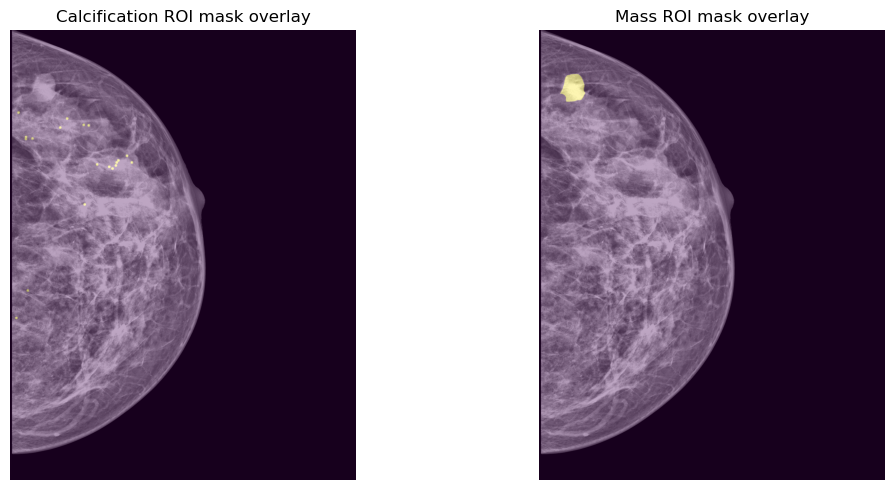

calc_mask pixels: 5957 | mass_mask pixels: 27717


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

FINAL_DIR = Path("data/processed/preproc_v1/final")  # adjust if needed

case_id = "22614522"
xml_path = Path(f"data/raw/AllXML/{case_id}.xml")

# find the row
match = link_df[link_df["case_id"] == case_id]
assert len(match) > 0, f"No DICOM found in link_df for case_id={case_id}"

row = match.iloc[0]

# derive stem from dicom filename/path
stem = Path(row["dicom_name"]).stem if "dicom_name" in row else Path(row["dicom_path"]).stem

img_path = FINAL_DIR / f"{stem}.npy"
assert img_path.exists(), f"Preprocessed image not found: {img_path}"

img = np.load(img_path).astype(np.float32)

rois = parse_inbreast_plist_xml(xml_path)
print("stem:", stem)
print("XML:", xml_path.name)
print("ROIs found:", len(rois))
print("ROI name counts:", dict(pd.Series([r["name"] for r in rois]).value_counts().head(10)))

# build masks by type
def name_is(n, key):
    return key.lower() in (n or "").lower()

calc_rois = [r for r in rois if name_is(r["name"], "calc")]
mass_rois = [r for r in rois if name_is(r["name"], "mass")]

calc_mask = np.zeros_like(img, dtype=np.uint8)
for r in calc_rois:
    calc_mask |= roi_to_mask(r, img.shape, point_radius=10)

mass_mask = np.zeros_like(img, dtype=np.uint8)
for r in mass_rois:
    mass_mask |= roi_to_mask(r, img.shape, point_radius=10)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.imshow(calc_mask, alpha=0.35)
plt.title("Calcification ROI mask overlay")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img, cmap="gray")
plt.imshow(mass_mask, alpha=0.35)
plt.title("Mass ROI mask overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("calc_mask pixels:", int(calc_mask.sum()), "| mass_mask pixels:", int(mass_mask.sum()))

C:\Users\nabee\AppData\Local\Temp\ipykernel_35812\2556603713.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, True, False, True, False, True, True, True, False, True, False, True, True, True, True, False, False, True, True, False, True, False, True, False, True, True, False, True, False, False, False, False, False, False, True, False, True, True, True, True, True, True, True, False, False, False, False, True, True, True, True, False, True, False, True, True, False, True, False, False, True, False, True, False, True, True, False, True, False, True, False, True, False, True, True, False, True, False, True, False, True, False, True, True, True, True, True, False, True, False, False, False, False, False, False, False, True, True, True, False, True, False, F

Total final images: 410
With XML: 343
With Mass ROI: 107
Saved patches: 321 -> data\processed\patches_v1\manifest.csv


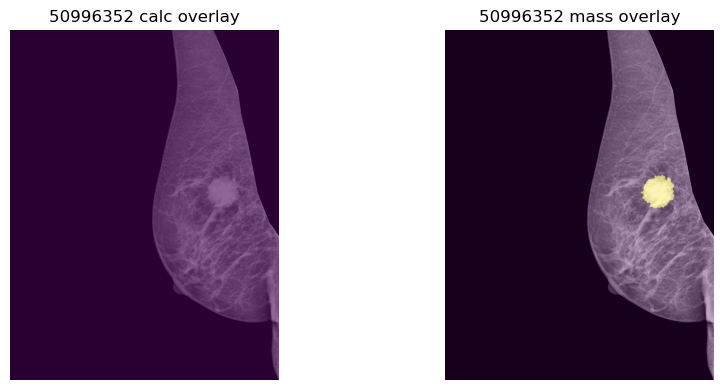

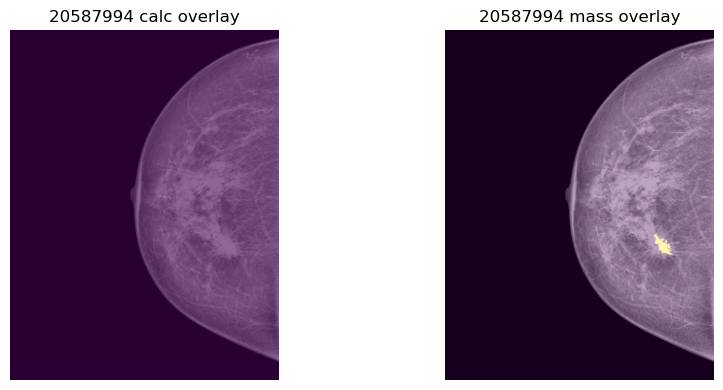

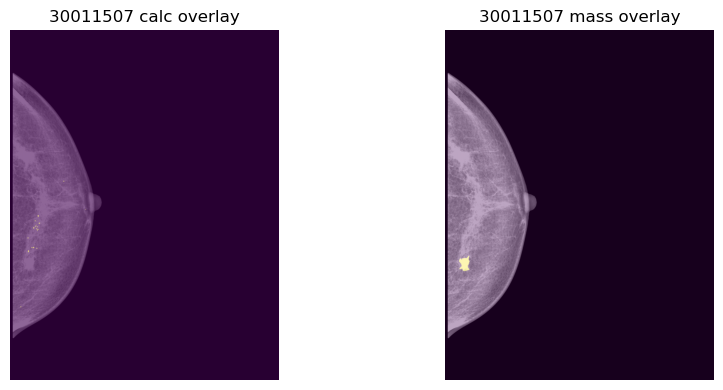

In [7]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import plistlib

# =========================
# EDIT PATHS
PREPROC_DIR = Path("data/processed/preproc_v1")
FINAL_DIR   = PREPROC_DIR / "final"        # *.npy final images (your preprocessed output)
BMASK_DIR   = PREPROC_DIR / "breast_mask"  # *.npy breast masks (your preprocessed output)
XML_DIR     = Path("data/raw/AllXML")      # Kaggle AllXML folder

OUT_DIR     = Path("data/processed/patches_v1")
OUT_MASS    = OUT_DIR / "mass"
OUT_BG      = OUT_DIR / "background"
MANIFEST    = OUT_DIR / "manifest.csv"

# If you have a metadata/index file with ACR + BIRADS etc, point to it:
# (Otherwise you can still generate patches + fill labels later.)
META_PATH   = None  # e.g. Path("data/processed/inbreast_meta.csv")
# =========================

OUT_MASS.mkdir(parents=True, exist_ok=True)
OUT_BG.mkdir(parents=True, exist_ok=True)

def parse_points_px(point_strings):
    """'(x, y)' strings -> Nx2 float array."""
    pts = []
    for s in point_strings:
        s = s.strip().lstrip("(").rstrip(")")
        x, y = s.split(",")[:2]
        pts.append((float(x), float(y)))
    return np.array(pts, dtype=np.float32)

def parse_inbreast_plist_xml(xml_path: Path):
    """Returns list of ROI dicts with fields: name, points(Nx2)."""
    with open(xml_path, "rb") as f:
        plist = plistlib.load(f)

    rois_out = []
    for img in plist.get("Images", []):
        for roi in img.get("ROIs", []):
            name = roi.get("Name", "")
            pts  = parse_points_px(roi.get("Point_px", [])) if "Point_px" in roi else np.zeros((0,2), np.float32)
            rois_out.append({"name": name, "points": pts})
    return rois_out

def rois_to_mask(rois, shape_hw, roi_name, point_radius=4):
    """Union mask for ROIs matching roi_name."""
    H, W = shape_hw
    m = np.zeros((H, W), dtype=np.uint8)

    for r in rois:
        if r["name"] != roi_name:
            continue
        pts = r["points"]
        if pts.size == 0:
            continue

        # Clamp + round
        p = np.round(pts).astype(np.int32)
        p[:, 0] = np.clip(p[:, 0], 0, W - 1)
        p[:, 1] = np.clip(p[:, 1], 0, H - 1)

        if len(p) >= 3:
            cv2.fillPoly(m, [p], 1)
        else:
            # calcifications are often single points -> draw small disk
            x, y = int(p[0, 0]), int(p[0, 1])
            cv2.circle(m, (x, y), point_radius, 1, thickness=-1)

    return m

def bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1  # x0,y0,x1,y1

def crop_with_pad(img, x0,y0,x1,y1, pad=32):
    H, W = img.shape[:2]
    x0p = max(0, x0 - pad); y0p = max(0, y0 - pad)
    x1p = min(W, x1 + pad); y1p = min(H, y1 + pad)
    return img[y0p:y1p, x0p:x1p], (x0p,y0p,x1p,y1p)

def resize_224(img01):
    # expects float in [0,1]
    out = cv2.resize(img01, (224, 224), interpolation=cv2.INTER_AREA)
    return out

def save_patch_png(img01, path: Path):
    u8 = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    cv2.imwrite(str(path), u8)

def sample_background_patch(img01, valid_mask, size_range=(256, 768), min_valid_frac=0.90, max_tries=200):
    """
    Sample a random square patch from img01 where valid_mask==1 covers >= min_valid_frac of patch.
    Returns (patch01, bbox) or (None, None).
    """
    H, W = img01.shape
    ys, xs = np.where(valid_mask > 0)
    if len(xs) == 0:
        return None, None

    for _ in range(max_tries):
        s = random.randint(*size_range)
        # pick a random valid pixel as patch center
        idx = random.randrange(len(xs))
        cx, cy = xs[idx], ys[idx]
        x0 = cx - s // 2; y0 = cy - s // 2
        x1 = x0 + s; y1 = y0 + s
        if x0 < 0 or y0 < 0 or x1 > W or y1 > H:
            continue
        patch_mask = valid_mask[y0:y1, x0:x1]
        if patch_mask.mean() >= min_valid_frac:
            return img01[y0:y1, x0:x1], (x0,y0,x1,y1)

    return None, None

# ---------- load your preproc index (stem list) ----------
index_path = PREPROC_DIR / "preproc_index.csv"
assert index_path.exists(), f"Missing {index_path}. Did you run Step 1.1?"
pre = pd.read_csv(index_path)

# derive case_id from stem prefix (works for '22614522_xxx_MG_L_CC_ANON')
pre["case_id"] = pre["stem"].astype(str).str.split("_").str[0]
pre["xml_path"] = pre["case_id"].apply(lambda cid: XML_DIR / f"{cid}.xml")
pre["has_xml"] = pre["xml_path"].apply(lambda p: p.exists())

# optional: load metadata if you have it
meta = None
if META_PATH is not None:
    meta = pd.read_csv(META_PATH)
    # expected columns: case_id, acr (1-4), birads (string/number)
    # merge if available
    pre = pre.merge(meta, on="case_id", how="left")

# ---------- scan XMLs to keep only cases with Mass ROI ----------
def has_mass_roi(xml_path, shape_hw):
    rois = parse_inbreast_plist_xml(xml_path)
    mm = rois_to_mask(rois, shape_hw, "Mass")
    return int(mm.sum()) > 0

mass_flags = []
for _, row in pre[pre["has_xml"]].iterrows():
    stem = row["stem"]
    img = np.load(FINAL_DIR / f"{stem}.npy").astype(np.float32)
    mass_flags.append(has_mass_roi(row["xml_path"], img.shape))
pre.loc[pre["has_xml"], "has_mass_roi"] = mass_flags
pre["has_mass_roi"] = pre["has_mass_roi"].fillna(False)

mass_cases = pre[pre["has_mass_roi"]].copy()
print("Total final images:", len(pre))
print("With XML:", int(pre["has_xml"].sum()))
print("With Mass ROI:", len(mass_cases))

# ---------- generate patches ----------
rows = []
N_BG_PER_IMAGE = 2  # tweak to match desired counts

for _, row in mass_cases.iterrows():
    stem = row["stem"]
    case_id = row["case_id"]
    xml_path = row["xml_path"]

    img = np.load(FINAL_DIR / f"{stem}.npy").astype(np.float32)
    bmask = np.load(BMASK_DIR / f"{stem}.npy").astype(np.uint8)

    rois = parse_inbreast_plist_xml(xml_path)
    mass_mask = rois_to_mask(rois, img.shape, "Mass")
    calc_mask = rois_to_mask(rois, img.shape, "Calcification")

    bb = bbox_from_mask(mass_mask)
    if bb is None:
        continue

    # 1) MASS PATCH
    x0,y0,x1,y1 = bb
    mass_crop, mass_bb = crop_with_pad(img, x0,y0,x1,y1, pad=32)
    mass_patch = resize_224(mass_crop)

    mass_out = OUT_MASS / f"{stem}__mass.png"
    save_patch_png(mass_patch, mass_out)

    rows.append({
        "case_id": case_id,
        "stem": stem,
        "patch_type": "mass",
        "label": None,            # fill from BIRADS / malignancy later
        "bbox": mass_bb,
        "path": str(mass_out)
    })

    # 2) BACKGROUND PATCHES (exclude mass region)
    valid_bg = (bmask > 0).astype(np.uint8)
    valid_bg[mass_mask > 0] = 0

    for j in range(N_BG_PER_IMAGE):
        bg_crop, bg_bb = sample_background_patch(img, valid_bg, size_range=(256, 768), min_valid_frac=0.90)
        if bg_crop is None:
            continue
        bg_patch = resize_224(bg_crop)

        bg_out = OUT_BG / f"{stem}__bg{j}.png"
        save_patch_png(bg_patch, bg_out)

        rows.append({
            "case_id": case_id,
            "stem": stem,
            "patch_type": "background",
            "label": None,          # fill from ACR/density later
            "bbox": bg_bb,
            "path": str(bg_out)
        })

# save manifest
man = pd.DataFrame(rows)
OUT_DIR.mkdir(parents=True, exist_ok=True)
man.to_csv(MANIFEST, index=False)
print("Saved patches:", len(man), "->", MANIFEST)

# ---------- quick sanity: show 3 random mass cases ----------
sample = mass_cases.sample(min(3, len(mass_cases)), random_state=0)
for _, row in sample.iterrows():
    stem = row["stem"]
    case_id = row["case_id"]
    img = np.load(FINAL_DIR / f"{stem}.npy").astype(np.float32)
    rois = parse_inbreast_plist_xml(row["xml_path"])
    mm = rois_to_mask(rois, img.shape, "Mass")
    cm = rois_to_mask(rois, img.shape, "Calcification")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img, cmap="gray"); plt.imshow(cm, alpha=0.6); plt.title(f"{case_id} calc overlay"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(img, cmap="gray"); plt.imshow(mm, alpha=0.35); plt.title(f"{case_id} mass overlay"); plt.axis("off")
    plt.tight_layout(); plt.show()

cell 1